# 02 — Cohort & Retention Analysis
### Product Analytics & Experimentation — E-Commerce Funnel

**This notebook answers the follow-up question:** of the customers who do come back, *when* do they
come back, and does retention differ by when they were acquired? We'll build a monthly cohort
retention matrix, visualize it as a heatmap, and look at how long repeat customers take to return.


## 1. Setup

In [1]:
%pip install duckdb pandas matplotlib seaborn
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("../olist.duckdb")

existing = {r[0] for r in con.execute("SHOW TABLES").fetchall()}
needed = {"orders": "olist_orders_dataset.csv", "customers": "olist_customers_dataset.csv"}
for name, file in needed.items():
    if name not in existing:
        con.execute(f"CREATE OR REPLACE TABLE {name} AS "
                    f"SELECT * FROM read_csv_auto('../data/{file}')")

con.execute("SHOW TABLES").df()

Note: you may need to restart the kernel to use updated packages.


,name
0,customers
1,items
2,orders
3,payments
4,reviews


## 2. How many new customers did we acquire each month?

Before retention, it helps to see the acquisition trend — the size of each monthly cohort. A cohort's
retention is only meaningful relative to how many customers it started with.

In [2]:
acq = con.execute('''
    WITH first_orders AS (
        SELECT
            c.customer_unique_id,
            MIN(date_trunc('month', o.order_purchase_timestamp)) AS cohort_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
        GROUP BY c.customer_unique_id
    )
    SELECT cohort_month, COUNT(*) AS new_customers
    FROM first_orders
    GROUP BY cohort_month
    ORDER BY cohort_month
''').df()
acq.head(12)

,cohort_month,new_customers
0,2016-09-01,4
1,2016-10-01,321
2,2016-12-01,1
3,2017-01-01,764
4,2017-02-01,1752
5,2017-03-01,2636
6,2017-04-01,2352
7,2017-05-01,3596
8,2017-06-01,3139
9,2017-07-01,3894


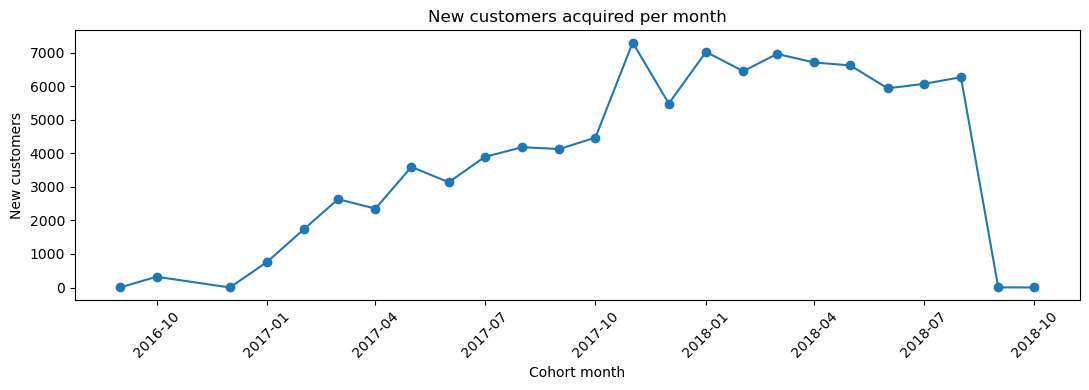

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(acq["cohort_month"], acq["new_customers"], marker="o")
ax.set_title("New customers acquired per month")
ax.set_xlabel("Cohort month")
ax.set_ylabel("New customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../reports/acquisition_by_month.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Build the cohort retention matrix

This is the query from `sql/cohort_retention.sql`. For every customer:
1. their **cohort** = the month of their first order,
2. for each later order, how many months after the cohort month it happened (**month_number**),
3. then count distinct customers active in each (cohort, month_number) cell.

The result is *long* format; we'll pivot it into a matrix next.

In [4]:
retention_long = con.execute('''
    WITH order_months AS (
        SELECT
            c.customer_unique_id,
            date_trunc('month', o.order_purchase_timestamp) AS order_month
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
    ),
    cohorts AS (
        SELECT customer_unique_id, MIN(order_month) AS cohort_month
        FROM order_months
        GROUP BY customer_unique_id
    ),
    activity AS (
        SELECT
            om.customer_unique_id,
            ch.cohort_month,
            date_diff('month', ch.cohort_month, om.order_month) AS month_number
        FROM order_months om
        JOIN cohorts ch ON om.customer_unique_id = ch.customer_unique_id
    )
    SELECT
        cohort_month,
        month_number,
        COUNT(DISTINCT customer_unique_id) AS customers
    FROM activity
    GROUP BY cohort_month, month_number
    ORDER BY cohort_month, month_number
''').df()

# Pivot long -> matrix: rows = cohort, columns = months since acquisition
counts = retention_long.pivot(index="cohort_month",
                              columns="month_number",
                              values="customers")
counts.iloc[:12, :8]   # peek at first 12 cohorts, first 8 months

month_number,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2016-09-01,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,321.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0
2017-02-01,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0
2017-03-01,2636.0,13.0,10.0,10.0,9.0,4.0,4.0,8.0
2017-04-01,2352.0,14.0,5.0,4.0,8.0,6.0,8.0,7.0
2017-05-01,3596.0,18.0,18.0,14.0,11.0,12.0,15.0,6.0
2017-06-01,3139.0,15.0,11.0,13.0,8.0,12.0,12.0,7.0


In [5]:
# Convert counts -> retention %: divide every cell by that cohort's month-0 size.
cohort_size = counts[0]
retention_pct = counts.divide(cohort_size, axis=0) * 100

# Keep the heatmap readable: first 13 months only (0-12).
retention_pct = retention_pct.loc[:, retention_pct.columns <= 12]
retention_pct.iloc[:12, :8].round(1)

month_number,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2016-09-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,100.0,NaN,NaN,NaN,NaN,NaN,0.3,NaN
2016-12-01,100.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,100.0,0.4,0.3,0.1,0.4,0.1,0.5,0.1
2017-02-01,100.0,0.2,0.3,0.1,0.4,0.1,0.2,0.2
2017-03-01,100.0,0.5,0.4,0.4,0.3,0.2,0.2,0.3
2017-04-01,100.0,0.6,0.2,0.2,0.3,0.3,0.3,0.3
2017-05-01,100.0,0.5,0.5,0.4,0.3,0.3,0.4,0.2
2017-06-01,100.0,0.5,0.4,0.4,0.3,0.4,0.4,0.2


## 4. Visualize retention as a heatmap

Rows are acquisition cohorts, columns are months since first purchase. Month 0 is always 100%
(everyone is active the month they join). What matters is how fast the numbers fall off to the right.

Expect this to look **very sparse** past month 0 — with a 3.1% repeat rate, retention is tiny. That
near-empty heatmap is itself the finding: this business barely retains anyone.

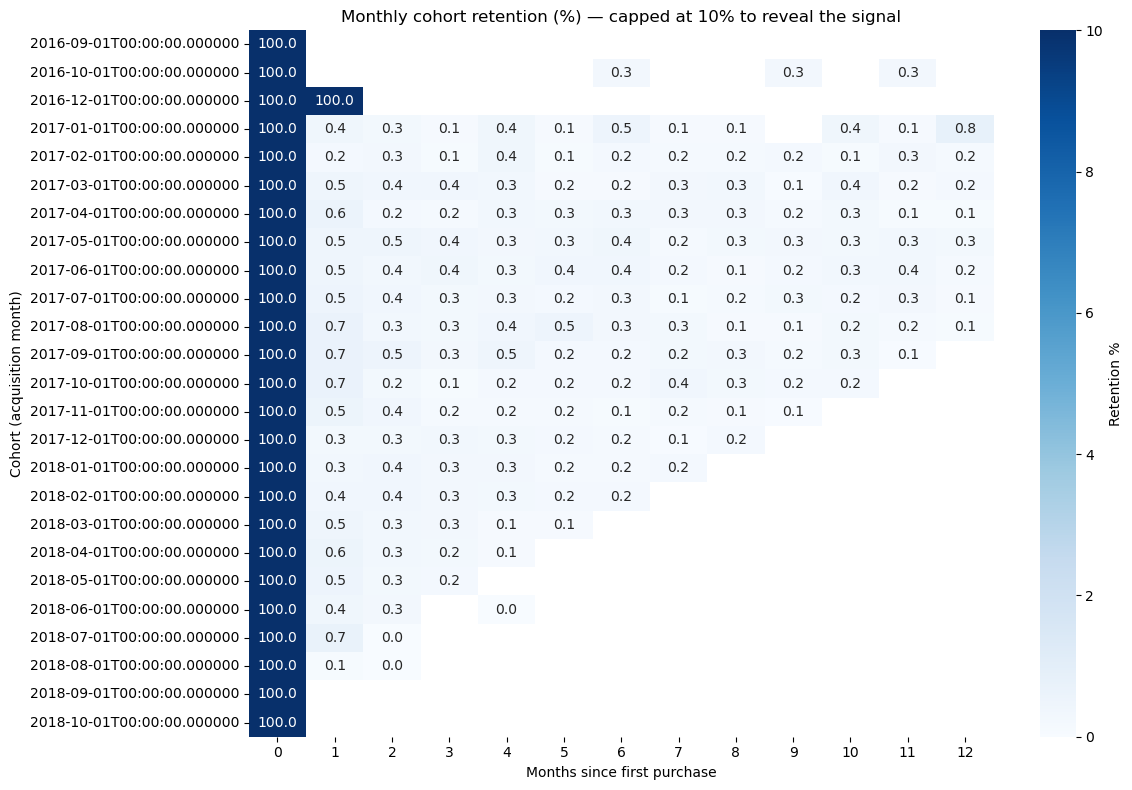

In [6]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    retention_pct,
    annot=True, fmt=".1f", cmap="Blues",
    vmin=0, vmax=10,          # cap at 10% so the tiny repeat signal is visible
    cbar_kws={"label": "Retention %"},
    ax=ax,
)
ax.set_title("Monthly cohort retention (%) — capped at 10% to reveal the signal")
ax.set_xlabel("Months since first purchase")
ax.set_ylabel("Cohort (acquisition month)")
plt.tight_layout()
plt.savefig("../reports/cohort_retention_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. When do repeat customers come back?

The heatmap shows retention is rare. For the customers who *do* return, how long do they take? This is
actionable: it tells the window in which a win-back nudge (email, coupon) would matter most.

In [7]:
gap = con.execute('''
    WITH cust_orders AS (
        SELECT c.customer_unique_id, o.order_purchase_timestamp AS ts
        FROM orders o
        JOIN customers c ON o.customer_id = c.customer_id
        WHERE o.order_purchase_timestamp IS NOT NULL
    ),
    ranked AS (
        SELECT customer_unique_id, ts,
               ROW_NUMBER() OVER (PARTITION BY customer_unique_id ORDER BY ts) AS rn
        FROM cust_orders
    ),
    first_second AS (
        SELECT customer_unique_id,
               MAX(CASE WHEN rn = 1 THEN ts END) AS first_ts,
               MAX(CASE WHEN rn = 2 THEN ts END) AS second_ts
        FROM ranked
        WHERE rn <= 2
        GROUP BY customer_unique_id
    )
    SELECT date_diff('day', first_ts, second_ts) AS days_to_second
    FROM first_second
    WHERE second_ts IS NOT NULL
''').df()

print(f"Repeat customers analyzed: {len(gap):,}")
gap["days_to_second"].describe()

Repeat customers analyzed: 2,997


count    2997.000000
mean       80.348348
std       110.191314
min         0.000000
25%         0.000000
50%        28.000000
75%       123.000000
max       609.000000
Name: days_to_second, dtype: float64

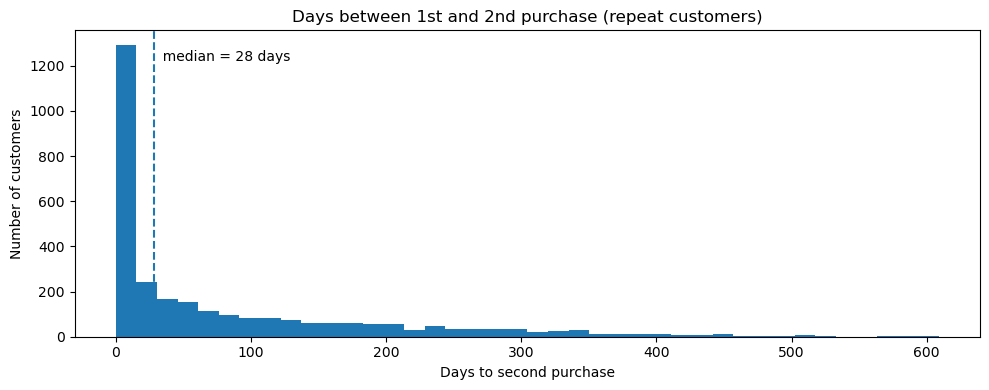

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gap["days_to_second"], bins=40)
median_days = gap["days_to_second"].median()
ax.axvline(median_days, linestyle="--")
ax.text(median_days, ax.get_ylim()[1]*0.9, f"  median = {median_days:.0f} days")
ax.set_title("Days between 1st and 2nd purchase (repeat customers)")
ax.set_xlabel("Days to second purchase")
ax.set_ylabel("Number of customers")
plt.tight_layout()
plt.savefig("../reports/days_to_second_purchase.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. What did we find? 

Retention is near-zero across all cohorts. No acquisition month retained customers meaningfully, confirming the 3.1% repeat rate is structural rather than tied to a bad period. Acquisition grew through 2017–2018 (the final-month drop is dataset truncation, not a real decline). Among the minority who do return, the median gap to a second purchase is ~28 days, suggesting any win-back campaign should fire within the first month after the first order.
